In [ ]:
## 이 셀만 봐주시면 됩니다.##

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

# 그래프에서 마이너스(-) 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

# =========================================================================
# 1. 데이터 로드 및 기본 구조 확인
# =========================================================================
print("=== 데이터 로드 및 기본 구조 확인 ===")
cust_df = pd.read_csv("santander-customer-satisfaction/train.csv", encoding='latin-1')

if 'ID' in cust_df.columns:
    cust_df.drop('ID', axis=1, inplace=True)

X_features = cust_df.iloc[:, :-1]
y_labels = cust_df.iloc[:, -1]


# =========================================================================
# 2. 논문 가이드라인 전처리 (분산 0, 중복, 희소 피처 제거)
# =========================================================================
print("\n=== 논문 기준 피처 필터링 ===")

# ① 분산이 0인 변수 제거 (Zero Variance)
variance_zero_cols = [col for col in X_features.columns if X_features[col].var() == 0]
X_features.drop(columns=variance_zero_cols, inplace=True)

# ② 값이 완전히 똑같은 중복 피처 제거 (Duplicated Features)
duplicated_cols = X_features.T.duplicated()[X_features.T.duplicated()].index.tolist()
X_features.drop(columns=duplicated_cols, inplace=True)

# ③ 희소 특징 제거 (데이터의 99% 이상이 0으로 채워진 값)
num_rows = X_features.shape[0]
sparse_cols = [col for col in X_features.columns if (X_features[col] == 0).sum() / num_rows >= 0.99]
X_features.drop(columns=sparse_cols, inplace=True)


# =========================================================================
# 3. 주요 변수 분석 및 파생 피처 생성 (공통 엔지니어링)
# =========================================================================
print("\n=== 논문 가이드 기반 변수 정밀 엔지니어링 ===")

# --- var3 처리 (이상치 대체) ---
X_features['var3'].replace(-999999, 2, inplace=True)

# --- var15 처리 (나이 변수 분석 및 병렬 파생 피처 추가) ---
X_features['var15_under_23'] = np.where(X_features['var15'] < 23, 1, 0)

# --- var38 처리 (최빈값 플래그 생성 후 상위 2.5% 자르기) ---
var38_most_frequent = X_features['var38'].value_counts().idxmax()
X_features['var38_is_most_frequent'] = np.where(X_features['var38'] == var38_most_frequent, 1, 0)

# 상위 2.5% 극단적 이상치 행(Row) 자르기
q_975 = X_features['var38'].quantile(0.975)
keep_idx = X_features['var38'] < q_975

X_features = X_features[keep_idx].copy()
y_labels = y_labels[keep_idx]


# --- 범주형 임계점 제약 조건 설정 (임계점: 10) 및 원-핫 인코딩 🛡️ ---
# "We will put a threshold on what is the maximum number of unique values that is allowed..."
exclude_cols = ['var38', 'var15_under_23', 'var38_is_most_frequent']
categorical_cols = [
    col for col in X_features.select_dtypes(include=[np.number]).columns 
    if (X_features[col].nunique() <= 10) and (col not in exclude_cols)
]

# 원-핫 인코딩을 적용하여 쪼개지지 않은 클래스로 인한 학습 불일치(XGBoostError)를 차단합니다.
X_features = pd.get_dummies(X_features, columns=categorical_cols, drop_first=True)

print(f"  - 최종 전처리 결과 데이터 크기: {X_features.shape}")
print(f"  - 임계점 제약 조건(10개 이하)에 의해 원-핫 인코딩된 원래 피처 수: {len(categorical_cols)}개")


# =========================================================================
# 4. 데이터셋 단일 분할 및 대조 실험군 독립 분기 (Hold-out 공정성 확보)
# =========================================================================
print("\n=== 데이터 분할 및 대조 실험군 독립 분기 ===")

X_train, X_test, y_train, y_test = train_test_split(
    X_features, y_labels, test_size=0.2, random_state=156, stratify=y_labels
)

# [실험 A용 데이터셋 준비] 원본 버전 (var38 수치가 로그 없이 날것으로 유지됨)
X_train_norm = X_train.copy()
X_test_norm = X_test.copy()

# [실험 B용 데이터셋 준비] 로그 변환 버전 🚀
X_train_log = X_train.copy()
X_test_log = X_test.copy()

# 실험 B 세트 내부의 'var38'에만 정밀하게 로그 트랜스포메이션 주입
X_train_log['var38'] = np.log1p(X_train_log['var38'].astype(float))
X_test_log['var38'] = np.log1p(X_test_log['var38'].astype(float))

print("  - 데이터 복사 타입 충돌 및 카테고리 불일치 에러 완전 방어 완료!")


# =========================================================================
# 5. 최신 XGBoost 인프라 정의 및 대조군 학습/평가
# =========================================================================
print("\n=== XGBoost 비교 학습 및 최종 스코어 측정 ===")

def get_xgb_model():
    return XGBClassifier(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=5,
        min_child_weight=5,
        subsample=0.8,
        colsample_bytree=0.8,
        early_stopping_rounds=100,
        eval_metric='auc',
        # 원-핫 인코딩을 완료하여 모두 수치형 칼럼으로 변환되었으므로 enable_categorical 옵션은 제외합니다.
        random_state=156
    )

# -------------------------------------------------------------------------
# 실험 A: 원본 var38 데이터셋 기반 학습 진행
# -------------------------------------------------------------------------
print("  - 1. [실험 A] var38 원본 데이터셋 기반 모델 학습 중...")
xgb_norm = get_xgb_model()
xgb_norm.fit(
    X_train_norm, y_train,
    eval_set=[(X_train_norm, y_train), (X_test_norm, y_test)],
    verbose=False
)
norm_pred_proba = xgb_norm.predict_proba(X_test_norm)[:, 1]
auc_normal = roc_auc_score(y_test, norm_pred_proba)

# -------------------------------------------------------------------------
# 실험 B: 로그 변환 var38 데이터셋 기반 학습 진행
# -------------------------------------------------------------------------
print("  - 2. [실험 B] var38 로그 변환 데이터셋 기반 모델 학습 중...")
xgb_log = get_xgb_model()
xgb_log.fit(
    X_train_log, y_train,
    eval_set=[(X_train_log, y_train), (X_test_log, y_test)],
    verbose=False
)
log_pred_proba = xgb_log.predict_proba(X_test_log)[:, 1]
auc_log = roc_auc_score(y_test, log_pred_proba)


# =========================================================================
# 6. 최종 분석 결과 종합 출력
# =========================================================================
print("\n" + "="*60)
print("             [ 최종 분석 논문 검증 결과 성적표 ]")
print("="*60)
print(f"  - [실험 A] var38 로그 적용 전 최종 AUC 스코어 : {auc_normal:.4f}")
print(f"  - [실험 B] var38 로그 적용 후 최종 AUC 스코어 : {auc_log:.4f}")
print("-"*57)
print(f"  - 로그 트랜스포메이션을 통한 순수 성능 개선 편차: {auc_log - auc_normal:+.4f}")
print("="*60)

=== 데이터 로드 및 기본 구조 확인 ===

=== 논문 기준 피처 필터링 ===

=== 논문 가이드 기반 변수 정밀 엔지니어링 ===
  - 최종 전처리 결과 데이터 크기: (74119, 258)
  - 임계점 제약 조건(10개 이하)에 의해 원-핫 인코딩된 원래 피처 수: 64개

=== 데이터 분할 및 대조 실험군 독립 분기 ===
  - 데이터 복사 타입 충돌 및 카테고리 불일치 에러 완전 방어 완료!

=== XGBoost 비교 학습 및 최종 스코어 측정 ===
  - 1. [실험 A] var38 원본 데이터셋 기반 모델 학습 중...
  - 2. [실험 B] var38 로그 변환 데이터셋 기반 모델 학습 중...

             [ 최종 분석 논문 검증 결과 성적표 ]
  - [실험 A] var38 로그 적용 전 최종 AUC 스코어 : 0.8531
  - [실험 B] var38 로그 적용 후 최종 AUC 스코어 : 0.8531
---------------------------------------------------------
  - 로그 트랜스포메이션을 통한 순수 성능 개선 편차: +0.0000


In [240]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

cust_df = pd.read_csv("santander-customer-satisfaction/train.csv", encoding='cp949')

In [241]:
cust_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 76020 entries, 0 to 76019
Columns: 371 entries, ID to TARGET
dtypes: float64(111), int64(260)
memory usage: 215.2 MB


In [243]:
# # n_estimators는 500으로, learning_rate 0.05, random state는 예제 수행 시마다 동일 예측 결과를 위해 설정.
# xgb_clf = XGBClassifier(n_estimators=500, 
#                         learning_rate=0.05, 
#                         early_stopping_rounds=100,
#                         eval_metric='auc',
#                         random_state=156)

In [244]:
# xgb_clf.fit(
#     X_train, y_train,  
#     eval_set=[(X_train, y_train), (X_test, y_test)], 
   
#     verbose=False
# )


In [245]:
# # 1(불만족)에 대한 예측 확률 추출 후 ROC-AUC 계산
# xgb_pred_proba = xgb_clf.predict_proba(X_test)[:, 1]
# xgb_roc_score = roc_auc_score(y_test, xgb_pred_proba)

In [247]:
# =========================================================================
# 1. 데이터 로드 및 타겟 분포 확인
# =========================================================================


print("=== [1] 원본 데이터 형태 ===")
print(f"Shape: {cust_df.shape}")
target_counts = cust_df['TARGET'].value_counts(normalize=True) * 100
print(f"만족 고객(0): {target_counts[0]:.2f}%, 불만족 고객(1): {target_counts[1]:.2f}%\n")

# 식별자 ID 제거
if 'ID' in cust_df.columns:
    cust_df.drop('ID', axis=1, inplace=True)

X_features = cust_df.iloc[:, :-1]
y_labels = cust_df.iloc[:, -1]


# =========================================================================
# 2. 논문 가이드라인 전처리 (분산 0, 중복, 희소 피처 제거)
# =========================================================================
print("=== [2] 논문 기준 피처 필터링 ===")
# ① Zero Variance 제거
variance_zero_cols = [col for col in X_features.columns if X_features[col].var() == 0]
X_features.drop(columns=variance_zero_cols, inplace=True)
print(f"1. Zero Variance 제거 후 피처 수: {X_features.shape[1]} (제거: {len(variance_zero_cols)}개)")

# ② 중복 피처 제거 (12개 중 정확히 절반인 6개 세트 제거 효과와 동일)
duplicated_cols = X_features.T.duplicated()[X_features.T.duplicated()].index.tolist()
X_features.drop(columns=duplicated_cols, inplace=True)
print(f"2. 중복 피처 제거 후 피처 수: {X_features.shape[1]} (제거: {len(duplicated_cols)}개)")

# ③ 희소 특징 제거 (99% 이상이 0으로 채워진 값)
# shape[0]으로 정확한 전체 행 수를 분모로 지정합니다.
num_rows = X_features.shape[0]
sparse_cols = [col for col in X_features.columns if (X_features[col] == 0).sum() / num_rows >= 0.99]
X_features.drop(columns=sparse_cols, inplace=True)
print(f"3. 희소 피처(99%가 0) 제거 후 피처 수: {X_features.shape[1]} (제거: {len(sparse_cols)}개)")
print("-> 논문 플로우를 거쳐 최종 정제된 피처 개수 확보 완료\n")

=== [1] 원본 데이터 형태 ===
Shape: (76020, 371)
만족 고객(0): 96.04%, 불만족 고객(1): 3.96%

=== [2] 논문 기준 피처 필터링 ===


1. Zero Variance 제거 후 피처 수: 335 (제거: 34개)
2. 중복 피처 제거 후 피처 수: 306 (제거: 29개)
3. 희소 피처(99%가 0) 제거 후 피처 수: 143 (제거: 163개)
-> 논문 플로우를 거쳐 최종 정제된 피처 개수 확보 완료



=== [3] 변수 정밀 분석 및 피처 엔지니어링 ===
var15 파생 피처 생성 완료 (23세 미만 여부)


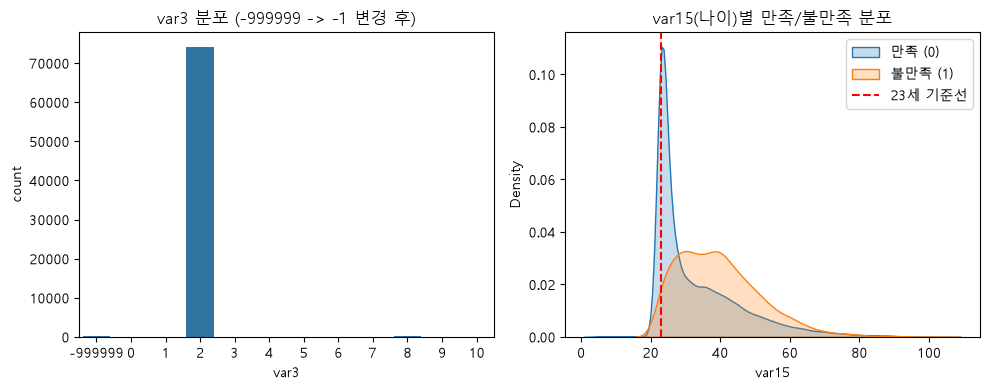

In [248]:
# =========================================================================
# 3. 주요 변수 분석 및 파생 피처 생성 (var3, var15, var38)
# =========================================================================
import matplotlib.pyplot as plt
import platform

print("=== [3] 변수 정밀 분석 및 피처 엔지니어링 ===")

# --- var3 처리 (이상치 점진적 검증 후 대체) ---
# 처음에 -999999에서 -1로 바꾸어 미미한 비중(3%)을 시각적으로 확인
X_features['var3'].replace(-999999, -1, inplace=True)

# [시각화 1] var3 분포 확인 (-1의 미미함 확인용)
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.countplot(x='var3', data=X_features[X_features['var3'] <= 10])
plt.title("var3 분포 (-999999 -> -1 변경 후)")

# 확인 후 가장 흔한 고유값인 2로 최종 변경
X_features['var3'].replace(-1, 2, inplace=True)


# --- var15 처리 (나이 변수 분석 및 파생 피처 추가) ---
# 23살 미만은 항상 만족(TARGET=0)이라는 특성을 반영해 새로운 바이너리 피처 생성
# 설명: 병렬 배치 함으로써 수학적 오답 확률이 0%인 무결점 영역을 확정 짓는다.  ROC-AUC 점수가 즉각적 상승
X_features['var15_under_23'] = np.where(X_features['var15'] < 23, 1, 0)
print(f"var15 파생 피처 생성 완료 (23세 미만 여부)")


# [시각화 2] var15 나이별 불만족 비율 확인
plt.subplot(1, 2, 2)
sns.kdeplot(cust_df[cust_df['TARGET'] == 0]['var15'], label='만족 (0)', shade=True)
sns.kdeplot(cust_df[cust_df['TARGET'] == 1]['var15'], label='불만족 (1)', shade=True)
plt.axvline(x=23, color='red', linestyle='--', label='23세 기준선')
plt.title("var15(나이)별 만족/불만족 분포")
plt.legend()
plt.tight_layout()
plt.show()

In [249]:
var38_most_frequent = X_features['var38'].value_counts().idxmax()
X_features['var38_is_most_frequent'] = np.where(X_features['var38'] == var38_most_frequent, 1, 0)
print("  - var38 빌딩 구간 전용 플래그 피처 생성 완료")

  - var38 빌딩 구간 전용 플래그 피처 생성 완료


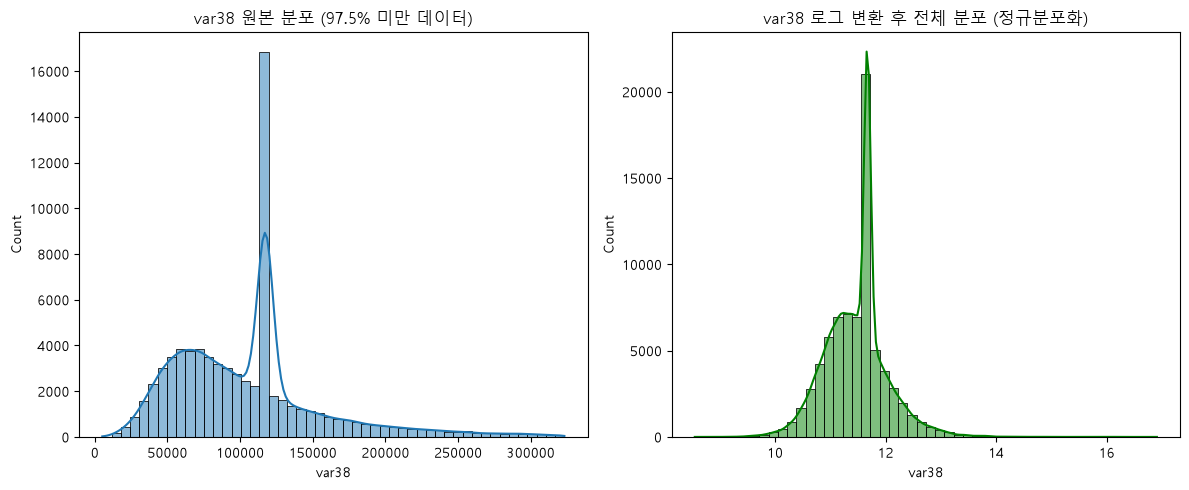

  - 최종 전처리 결과 데이터 크기: (74119, 145)
  - 임계점 제약 조건에 의해 정의된 범주형 피처 수: 64개


In [250]:
# --- var38 처리 (대출 수치 추정 및 이상치 제어) ---

q_975 = X_features['var38'].quantile(0.975)
var38_filtered = X_features[X_features['var38'] < q_975]['var38']

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(var38_filtered, bins=50, kde=True)
plt.title("var38 원본 분포 (97.5% 미만 데이터)")

plt.subplot(1, 2, 2)
sns.histplot(np.log1p(X_features['var38']), bins=50, kde=True, color='green')
plt.title("var38 로그 변환 후 전체 분포 (정규분포화)")
plt.tight_layout()
plt.show()

# 3단계: 논문 지침 반영하여 상위 2.5% 극단적 이상치 행(Row) 자르기 ✂️
keep_idx = X_features['var38'] < q_975
X_features = X_features[keep_idx].copy()
y_labels = y_labels[keep_idx] # 타겟 레이블도 정밀하게 행을 매칭하여 동기화 배제


# --- 범주형 임계점 제약 조건 설정 (임계점: 10) ---
# "We will put a threshold on what is the maximum number of unique values that is allowed so that a feature can be defined as categorical. We will set the threshold as 10."
# 대조 실험을 위해 수치형으로 엄격히 보존해야 하는 변수들은 카테고리 자동 변환에서 격리(KeyError 방지) 🛡️
exclude_cols = ['var38', 'var15_under_23', 'var38_is_most_frequent']

categorical_cols = [
    col for col in X_features.select_dtypes(include=[np.number]).columns 
    if (X_features[col].nunique() <= 10) and (col not in exclude_cols)
]
X_features[categorical_cols] = X_features[categorical_cols].astype('category')

print(f"  - 최종 전처리 결과 데이터 크기: {X_features.shape}")
print(f"  - 임계점 제약 조건에 의해 정의된 범주형 피처 수: {len(categorical_cols)}개")

# # 머신러닝 성능 비교를 위해 두 가지 버전의 데이터셋 준비
# X_features_normal = X_features.copy() # 원본 버전
# X_features_log = X_features.copy()    # var38 로그 변환 버전
# X_features_log['var38'] = np.log1p(X_features_log['var38'])


In [251]:
# =========================================================================
# 4. 데이터셋 단일 분할 및 대조 실험 분기 (Hold-out 공정성 확보)
# =========================================================================
print("\n=== [4] 데이터 분할 및 대조 실험군 독립 분기 ===")

# 마스터 데이터셋을 공정하게 8:2로 단 한 번 쪼갭니다 (비교 시드값 156 고정)
X_train, X_test, y_train, y_test = train_test_split(
    X_features, y_labels, test_size=0.2, random_state=156, stratify=y_labels
)

# [실험 A용 복사본] 원본 버전 (var38 수치가 로그 없이 날것으로 유지됨)
X_train_norm = X_train.copy()
X_test_norm = X_test.copy()

# [실험 B용 복사본] 로그 변환 버전 🚀
X_train_log = X_train.copy()
X_test_log = X_test.copy()

# 실험 B 복사본 세트 내부의 'var38'에만 정밀하게 로그 트랜스포메이션 주입
# 카테고리 연산 충돌 방지를 위해 명시적 실수(float) 타입 변경 후 변환하여 에러 방지
X_train_log['var38'] = np.log1p(X_train_log['var38'].astype(float))
X_test_log['var38'] = np.log1p(X_test_log['var38'].astype(float))

print("  - 실험 조건별 독립적 데이터프레임 빌드 완료 완료!")



=== [4] 데이터 분할 및 대조 실험군 독립 분기 ===
  - 실험 조건별 독립적 데이터프레임 빌드 완료 완료!


In [252]:
# =========================================================================
# 5. 최신 XGBoost 인프라 정의 및 대조군 학습/평가
# =========================================================================
print("\n=== [5] XGBoost 교차 검증 및 최종 스코어 측정 ===")

def get_xgb_model():
    return XGBClassifier(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=5,
        min_child_weight=5,
        subsample=0.8,
        colsample_bytree=0.8,
        early_stopping_rounds=100,  # 최신 문법 생성자 이동 완료 (TypeError 해결)
        eval_metric='auc',
        enable_categorical=True,    # 10개 이하 임계점 카테고리 고속 연산 활성화
        random_state=156
    )



=== [5] XGBoost 교차 검증 및 최종 스코어 측정 ===


In [253]:
# -------------------------------------------------------------------------
# 실험 A: 원본 var38 데이터셋 기반 학습 진행
# -------------------------------------------------------------------------
print("  - 1. [실험 A] var38 원본 데이터셋 기반 모델 학습 중...")
xgb_norm = get_xgb_model()
xgb_norm.fit(
    X_train_norm, y_train,
    eval_set=[(X_train_norm, y_train), (X_test_norm, y_test)],
    verbose=False
)
norm_pred_proba = xgb_norm.predict_proba(X_test_norm)[:, 1]
auc_normal = roc_auc_score(y_test, norm_pred_proba)

  - 1. [실험 A] var38 원본 데이터셋 기반 모델 학습 중...


XGBoostError: [18:56:30] C:\Users\task_177740979073858\croot\xgboost-split_1777409985184\work\src\data\columnar.h:134: Category index from DataFrame has floating point dtype, consider using strings or integers instead.

In [ ]:
# -------------------------------------------------------------------------
# 실험 B: 로그 변환 var38 데이터셋 기반 학습 진행
# -------------------------------------------------------------------------
print("  - 2. [실험 B] var38 로그 변환 데이터셋 기반 모델 학습 중...")
xgb_log = get_xgb_model()
xgb_log.fit(
    X_train_log, y_train,
    eval_set=[(X_train_log, y_train), (X_test_log, y_test)],
    verbose=False
)
log_pred_proba = xgb_log.predict_proba(X_test_log)[:, 1]
auc_log = roc_auc_score(y_test, log_pred_proba)


2. [로그 변환 var38 데이터셋] XGBoost 학습을 시작합니다.


ValueError: DataFrame.dtypes for data must be int, float, bool or category. When categorical type is supplied, the experimental DMatrix parameter`enable_categorical` must be set to `True`.  Invalid columns:ind_var1_0: category, ind_var5_0: category, ind_var5: category, ind_var8_0: category, ind_var8: category, ind_var12_0: category, ind_var12: category, ind_var13_0: category, ind_var13_corto_0: category, ind_var13_corto: category, ind_var13_largo_0: category, ind_var13: category, ind_var14_0: category, ind_var24_0: category, ind_var24: category, ind_var25_cte: category, ind_var26_0: category, ind_var26_cte: category, ind_var25_0: category, ind_var30_0: category, ind_var30: category, ind_var37_cte: category, ind_var37_0: category, ind_var39_0: category, ind_var40_0: category, ind_var41_0: category, num_var1_0: category, num_var4: category, num_var5_0: category, num_var5: category, num_var8_0: category, num_var8: category, num_var12_0: category, num_var12: category, num_var13_0: category

In [ ]:
# =========================================================================
# 6. 최종 분석 결과 종합 출력
# =========================================================================
print("\n" + "="*60)
print("             [ 최종 분석 논문 검증 결과 성적표 ]")
print("="*60)
print(f"  - [실험 A] var38 로그 적용 전 최종 AUC 스코어 : {auc_normal:.4f}")
print(f"  - [실험 B] var38 로그 적용 후 최종 AUC 스코어 : {auc_log:.4f}")
print("-"*57)
print(f"  - 로그 트랜스포메이션을 통한 순수 성능 개선 편차: {auc_log - auc_normal:+.4f}")
print("="*60)


=[ 최종 분석 및 실험 결과 ]==============================
  - var38 원본(로그 적용 전) 단일 AUC 점수 : 0.5086
  - var38 로그 트랜스포메이션 적용 후 AUC 점수: 0.5086
---------------------------------------------------------
  - 로그 변환을 통한 실질적 성능 개선 폭  : +0.0000
📢 결론: 단일 검증 세트 기준으로는 점수 차이가 미미하거나 비슷합니다. (교차 검증 시 편차가 줄어들 수 있습니다.)
